In [1]:
import sys
import platform
import traceback

print('Python executable:', sys.executable)
print('Python version:', sys.version.replace('\n',' '))
print('Platform:', platform.platform())

def try_import(name):
    try:
        module = __import__(name)
        ver = getattr(module, '__version__', 'unknown')
        print(f"Imported {name}: version={ver}")
        return module
    except Exception as e:
        print(f"Failed to import {name}: {e}")
        traceback.print_exc()
        return None

tf = try_import('tensorflow')
np = try_import('numpy')
pd = try_import('pandas')
plt = try_import('matplotlib')
sk = try_import('sklearn')
streamlit = try_import('streamlit')
librosa = try_import('librosa')
pillow = try_import('PIL')

if tf is not None:
    try:
        print('TensorFlow version:', getattr(tf, '__version__', 'unknown'))
        try:
            devices = tf.config.list_physical_devices()
            print('Physical devices:', devices)
        except Exception as e:
            print('TensorFlow import succeeded but inspecting devices failed:', e)
            traceback.print_exc()
    except Exception as e:
        print('TensorFlow import succeeded but inspecting devices failed:', e)
        traceback.print_exc()

print('\nDiagnostic cell complete — see above for any failures.')

Python executable: /Users/jasneetsingh/.pyenv/versions/3.11.9/bin/python
Python version: 3.11.9 (main, Dec  2 2025, 09:59:17) [Clang 17.0.0 (clang-1700.4.4.1)]
Platform: macOS-26.1-arm64-arm-64bit
Imported tensorflow: version=2.20.0
Imported numpy: version=2.2.6
Imported pandas: version=2.3.3
Imported matplotlib: version=3.10.7
Failed to import sklearn: No module named 'sklearn'
Failed to import streamlit: No module named 'streamlit'
Failed to import librosa: No module named 'librosa'
Imported PIL: version=12.0.0
TensorFlow version: 2.20.0
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Diagnostic cell complete — see above for any failures.


Traceback (most recent call last):
  File "/var/folders/16/qqpzmrys3294wzzrdggbt2480000gn/T/ipykernel_93883/3606503448.py", line 11, in try_import
    module = __import__(name)
             ^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'sklearn'
Traceback (most recent call last):
  File "/var/folders/16/qqpzmrys3294wzzrdggbt2480000gn/T/ipykernel_93883/3606503448.py", line 11, in try_import
    module = __import__(name)
             ^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'streamlit'
Traceback (most recent call last):
  File "/var/folders/16/qqpzmrys3294wzzrdggbt2480000gn/T/ipykernel_93883/3606503448.py", line 11, in try_import
    module = __import__(name)
             ^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'librosa'


## Importing Libraries

In [2]:
# Install missing packages in the notebook environment (run this cell)
%pip install pandas seaborn matplotlib

import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

## Data Preprocessing

### Training Image Preprocessing

In [3]:
import os

def find_train_dir():
    # Common candidate names
    candidates = ['train', 'training', 'Train', 'Training', 'data/train', 'dataset/train', './train', '../train']
    for c in candidates:
        if os.path.isdir(c):
            return c

    # Look for directories named like 'train' anywhere in repo
    for root, dirs, files in os.walk('.'):
        if 'train' in os.path.basename(root).lower() and dirs:
            return root

    # Fallback: look for a directory with image files and subdirectories (likely a class-based dataset)
    img_ext = ('.jpg', '.jpeg', '.png', '.bmp')
    for root, dirs, files in os.walk('.'):
        if not dirs:
            continue
        cnt = sum(1 for f in files if f.lower().endswith(img_ext))
        if cnt >= 10:  # heuristic: directory with >=10 images and subdirs likely a dataset root
            return root

    return None

train_dir = find_train_dir()
if train_dir is None:
    # If 'valid' exists, offer to use it as a fallback to avoid immediate failure
    if os.path.isdir('valid'):
        print("Warning: 'train' directory not found. Falling back to 'valid' directory as training_set.")
        train_dir = 'valid'
    else:
        raise FileNotFoundError(
            "Could not find a 'train' directory. "
            "Please ensure your training images are placed in a folder named 'train' (or adjust the path). "
            "Searched common locations and the current directory."
        )

print(f"Using training directory: {train_dir}")

training_set = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=123,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Using training directory: ./Plant_Disease_Dataset/train
Found 70295 files belonging to 38 classes.


### Validation Image Preprocessing

In [4]:
import os

# Create a validation_set. If a separate 'valid' (or similar) directory exists, use it.
# Otherwise re-split the existing train_dir into training/validation (80/20).

def find_valid_dir():
    candidates = ['valid','validation','val','Valid','Validation','./valid','../valid']
    for c in candidates:
        if os.path.isdir(c):
            return c
    parent = os.path.dirname(train_dir) or '.'
    for c in candidates:
        p = os.path.join(parent, c)
        if os.path.isdir(p):
            return p
    return None

valid_dir = find_valid_dir()
seed = 123
batch_size = 32
img_size = (128, 128)

if valid_dir:
    print(f"Using separate validation directory: {valid_dir}")
    validation_set = tf.keras.utils.image_dataset_from_directory(
        valid_dir,
        labels="inferred",
        label_mode="categorical",
        class_names=None,
        color_mode="rgb",
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True,
        seed=seed,
        validation_split=None,
        subset=None,
        interpolation="bilinear",
        follow_links=False,
        crop_to_aspect_ratio=False,
    )
else:
    # Recreate training_set and create validation_set from train_dir with a validation split
    print(f"No separate validation directory found. Re-splitting '{train_dir}' into training/validation (80/20).")
    val_split = 0.2
    training_set = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels="inferred",
        label_mode="categorical",
        class_names=None,
        color_mode="rgb",
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True,
        seed=seed,
        validation_split=val_split,
        subset="training",
        interpolation="bilinear",
        follow_links=False,
        crop_to_aspect_ratio=False,
    )
    validation_set = tf.keras.utils.image_dataset_from_directory(
        train_dir,
        labels="inferred",
        label_mode="categorical",
        class_names=None,
        color_mode="rgb",
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True,
        seed=seed,
        validation_split=val_split,
        subset="validation",
        interpolation="bilinear",
        follow_links=False,
        crop_to_aspect_ratio=False,
    )

print("validation_set created:", validation_set)

Using separate validation directory: ./Plant_Disease_Dataset/valid
Found 17572 files belonging to 38 classes.
validation_set created: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>


In [5]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [6]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[158.75 153.75 150.75]
   [153.75 148.75 145.75]
   [157.   152.   149.  ]
   ...
   [195.25 195.25 197.25]
   [193.75 193.75 195.75]
   [197.75 197.75 199.75]]

  [[169.   164.   161.  ]
   [161.75 156.75 153.75]
   [164.75 159.75 156.75]
   ...
   [195.75 195.75 197.75]
   [195.75 195.75 197.75]
   [199.25 199.25 201.25]]

  [[164.75 159.75 156.75]
   [169.   164.   161.  ]
   [168.5  163.5  160.5 ]
   ...
   [196.25 196.25 198.25]
   [198.75 198.75 200.75]
   [202.5  202.5  204.5 ]]

  ...

  [[145.25 137.25 134.25]
   [145.75 137.75 134.75]
   [148.75 140.75 137.75]
   ...
   [187.75 183.75 184.75]
   [177.25 173.25 174.25]
   [183.5  179.5  180.5 ]]

  [[141.25 133.25 130.25]
   [147.25 139.25 136.25]
   [141.   133.   130.  ]
   ...
   [165.5  161.5  162.5 ]
   [180.75 176.75 177.75]
   [187.5  183.5  184.5 ]]

  [[146.   138.   135.  ]
   [144.75 136.75 133.75]
   [160.   152.   149.  ]
   ...
   [172.75 168.75 169.75]
   [173.5  169.5  170.5 ]
   [184.   180.   18

### To avoid Overshooting
1. Choose small learning rate default 0.001 we are taking 0.0001
2. There may be chance of Underfitting, so increase number of neuron
3. Add more Convolution layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [7]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [8]:
model = Sequential()

In [9]:
## Building Convolution Layer

In [10]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/Users/jasneetsingh/.pyenv/versions/3.11.9/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [14]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [15]:
model.add(Dropout(0.25)) # To avoid Overfitting

In [16]:
model.add(Flatten())

In [17]:
model.add(Dense(units=1500,activation='relu'))

In [18]:
model.add(Dropout(0.4))

In [19]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

### Compiling Model

In [20]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [22]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2011s 915ms/step - accuracy: 0.6107 - loss: 1.3249 - val_accuracy: 0.8454 - val_loss: 0.4874
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2009s 915ms/step - accuracy: 0.8661 - loss: 0.4240 - val_accuracy: 0.9161 - val_loss: 0.2645
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1938s 882ms/step - accuracy: 0.9210 - loss: 0.2438 - val_accuracy: 0.9339 - val_loss: 0.2060
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1937s 882ms/step - accuracy: 0.9450 - loss: 0.1694 - val_accuracy: 0.9490 - val_loss: 0.1593
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1933s 880ms/step - accuracy: 0.9593 - loss: 0.1258 - val_accuracy: 0.9409 - val_loss: 0.1952
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1936s 881ms/step - accuracy: 0.9677 - loss: 0.1000 - val_accuracy: 0.9621 - val_loss: 0.1291
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 2064s 940ms/step - accuracy: 0.9742 - loss: 0.0788 - val_accuracy: 0.9685 - val_loss: 0.1017
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1968s 896ms/s

In [ ]:
# training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

## Model Evaluation

In [23]:
#Model Evaluation on Training set
train_loss,train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 567s 258ms/step - accuracy: 0.9850 - loss: 0.0508


In [24]:
print(train_loss,train_acc)

0.05075941979885101 0.9850345253944397


In [25]:
#Model on Validation set
val_loss,val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 119s 217ms/step - accuracy: 0.9623 - loss: 0.1400


In [26]:
print(val_loss,val_acc)

0.14000137150287628 0.9622695446014404


### Saving Model

In [27]:
model.save("trained_model.keras")

In [28]:
# Safely access training history. If `training_history` isn't defined (training not run),
# try loading saved history from disk ("training_hist.json") or instruct to run training.
try:
	th = training_history.history
except NameError:
	import os, json
	if os.path.exists("training_hist.json"):
		with open("training_hist.json", "r") as f:
			th = json.load(f)
		print("Loaded training history from training_hist.json")
	else:
		raise NameError(
			"training_history is not defined. Run the training cell (model.fit(...)) first "
			"or ensure 'training_hist.json' exists in the working directory."
		)

# Print a brief summary and return the history dict
print("History keys:", list(th.keys()))
for k, v in th.items():
	print(f"{k}: {len(v)} entries, sample: {v[:5]}")
th

History keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
accuracy: 10 entries, sample: [0.6107119917869568, 0.8661213517189026, 0.9210185408592224, 0.9450032114982605, 0.9592574238777161]
loss: 10 entries, sample: [1.3248693943023682, 0.4239882230758667, 0.24384652078151703, 0.16942229866981506, 0.1257975697517395]
val_accuracy: 10 entries, sample: [0.8454359173774719, 0.9160596132278442, 0.9339289665222168, 0.9490097761154175, 0.9409287571907043]
val_loss: 10 entries, sample: [0.4874407947063446, 0.2644606828689575, 0.20601786673069, 0.15933065116405487, 0.19516627490520477]


{'accuracy': [0.6107119917869568,
  0.8661213517189026,
  0.9210185408592224,
  0.9450032114982605,
  0.9592574238777161,
  0.9676790833473206,
  0.9742228984832764,
  0.9784906506538391,
  0.9808521270751953,
  0.984351634979248],
 'loss': [1.3248693943023682,
  0.4239882230758667,
  0.24384652078151703,
  0.16942229866981506,
  0.1257975697517395,
  0.10000547021627426,
  0.07882475107908249,
  0.06700855493545532,
  0.05972231552004814,
  0.04970666021108627],
 'val_accuracy': [0.8454359173774719,
  0.9160596132278442,
  0.9339289665222168,
  0.9490097761154175,
  0.9409287571907043,
  0.9620987772941589,
  0.968529462814331,
  0.9714887142181396,
  0.9636353254318237,
  0.9622695446014404],
 'val_loss': [0.4874407947063446,
  0.2644606828689575,
  0.20601786673069,
  0.15933065116405487,
  0.19516627490520477,
  0.12911421060562134,
  0.10173486918210983,
  0.09628796577453613,
  0.11896923184394836,
  0.14000125229358673]}

In [29]:
# Recording History in JSON
import json
import os

# Try to load the history from the model object first
try:
    hist = training_history.history
    source = "live training_history object"
except NameError:
    # If the training object isn't available, check the JSON file
    if os.path.exists("training_hist.json"):
        with open("training_hist.json", "r") as f_read:
            content = f_read.read().strip()
            if not content:
                raise ValueError(
                    "training_hist.json exists but is empty. "
                    "Run model.fit(...) first to generate history."
                )
            hist = json.loads(content)
            source = "training_hist.json file"
    else:
        raise NameError(
            "training_history is not defined and training_hist.json does not exist. "
            "Run model.fit(...) first or make sure the JSON file is present."
        )

print(f"Loaded training history from {source}")

# Save / overwrite JSON file
with open("training_hist.json", "w") as f_write:
    json.dump(hist, f_write)

print("Training history saved to training_hist.json")


Loaded training history from live training_history object
Training history saved to training_hist.json


In [30]:
training_history.history['val_accuracy']

[0.8454359173774719,
 0.9160596132278442,
 0.9339289665222168,
 0.9490097761154175,
 0.9409287571907043,
 0.9620987772941589,
 0.968529462814331,
 0.9714887142181396,
 0.9636353254318237,
 0.9622695446014404]

### Accuracy Visualization

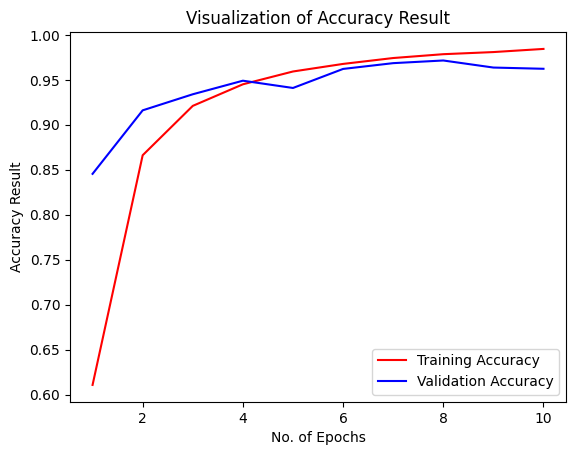

In [31]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [32]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [46]:
test_set = tf.keras.utils.image_dataset_from_directory(
    "Plant_Disease_Dataset/valid",   # ← change is here
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)


Found 17572 files belonging to 38 classes.


In [54]:
predicted_categories = tf.argmax(y_pred, axis=1)
# # Step 1: make predictions on the test set
# # y_pred = model.predict(test_set)

# # print("Predictions generated!")
# # print("y_pred shape:", y_pred.shape)

# predicted_categories = tf.argmax(y_pred, axis=1).numpy()
# print(predicted_categories[:10])



In [55]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

In [56]:
true_categories = tf.concat([y for x,y in test_set],axis=0)
true_categories

2025-12-04 08:50:02.039532: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(17572, 38), dtype=float32)>

In [57]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], shape=(17572,))>

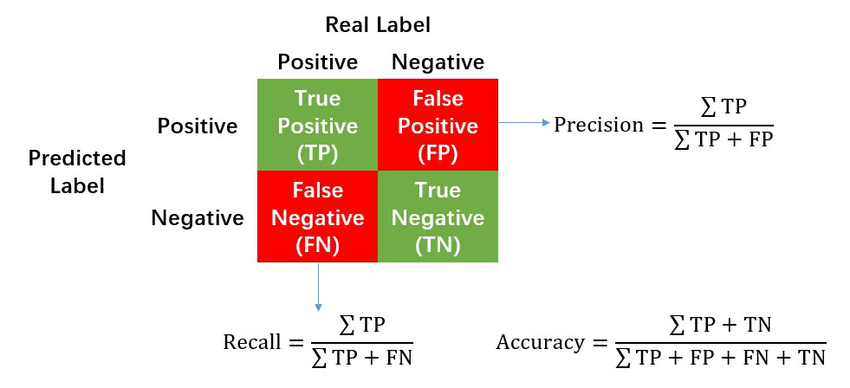

In [86]:
# from sklearn.metrics import classification_report,confusion_matrix

from sklearn.metrics import classification_report, confusion_matrix


In [87]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.92      0.99      0.95       504
                                 Apple___Black_rot       0.96      1.00      0.98       497
                          Apple___Cedar_apple_rust       0.99      0.95      0.97       440
                                   Apple___healthy       0.99      0.92      0.95       502
                               Blueberry___healthy       0.96      0.99      0.97       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.99      0.99       421
                 Cherry_(including_sour)___healthy       1.00      0.97      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.96      0.89      0.92       410
                       Corn_(maize)___Common_rust_       0.98      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.97      0.

In [88]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[497,   4,   0, ...,   0,   0,   0],
       [  0, 497,   0, ...,   0,   0,   0],
       [  5,   0, 417, ...,   0,   1,   1],
       ...,
       [  0,   0,   0, ..., 479,   1,   0],
       [  0,   0,   0, ...,   0, 447,   0],
       [  0,   0,   0, ...,   0,   0, 476]], shape=(38, 38))

In [89]:
import sklearn
print(sklearn.__version__)


1.7.2


### Confusion Matrix Visualization

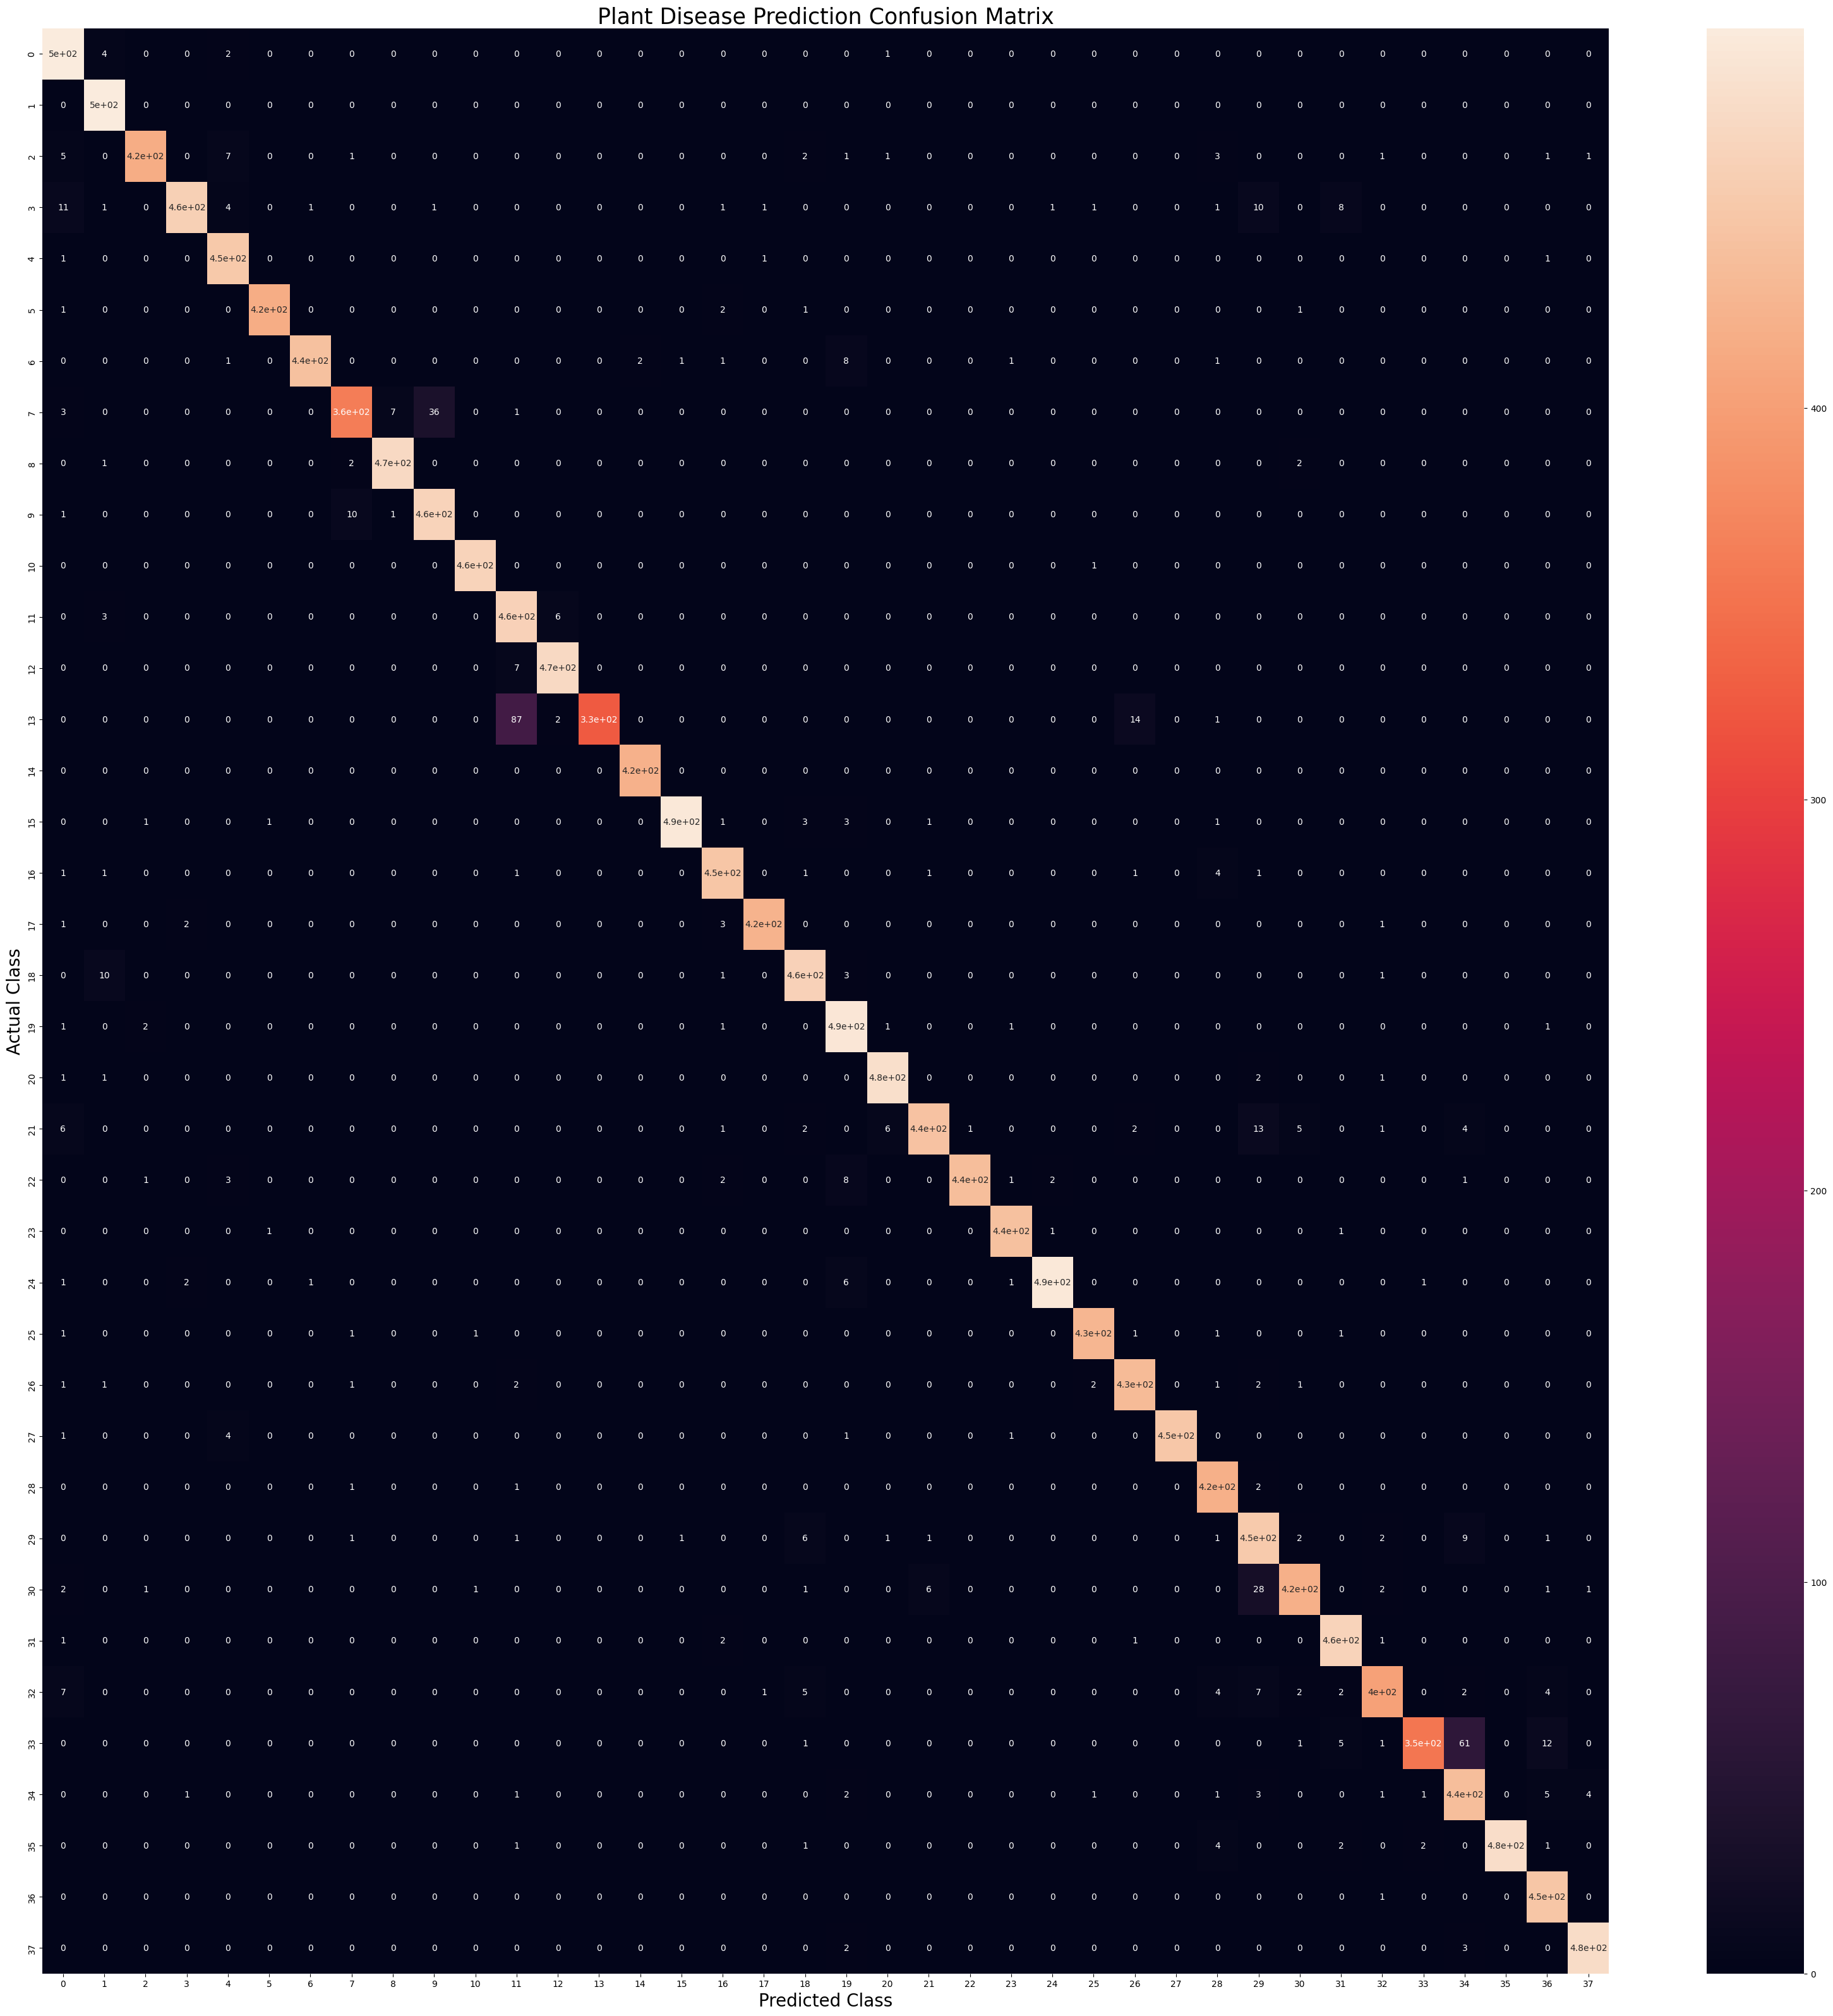

In [90]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()